# Unsupervised hierarchical clustering applied to IFU data cubes

This notebook provides a compact, runnable version of the clustering method developed in Hermosa Muñoz et al. (2025b) with the basic steps:
1. Load a cube using `modules.cube.cube`
2. Run hierarchical clustering (`modules.hcluster.hcluster`)
3. Plot the cluster map
4. Plot the median spectrum of each cluster

It has been tested with python 3.9 and 3.11.3 (any version > 3.9 should work).

The second cell has the paths and file selection, to be edited for the cube you want to run.

Each block has comments that explain the code, as well as the parameters that can be modified. 

In [1]:
import os
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

# workspace modules
from modules.cube import cube
from modules.hcluster import hcluster, spectra_similarity_corr

date = datetime.now().strftime('%d%m%Y')


### Load the cube

Set the filename of the cube, and the path to save the figures (if selected, see below)

In [ ]:
# === USER CONFIG ===
# Change this to the cube you want to analyze
fname = '/home/lhermosa/Desktop/CAB/DATA/GATOS/NGC7172/Level3_ch3-shortmediumlong_s3d_ergs_bkg.fits' 
gal = 'NGC7172'
# Change the saving path to your desired location
SavePath = os.path.expanduser(f'~/Desktop/quick_runs/{gal}/')
os.makedirs(SavePath, exist_ok=True)
print('[INFO]: The produced figures will be saved in path:', SavePath)


[INFO]: The produced figures will be saved in path: /home/lhermosa/Desktop/CAB/quick_runs/NGC7172/


In [ ]:
# === Load cube ===

# Load the cube with different methods in case of failure
# In this step, the wavelength is computed from the header information by default.
# If it fails, a fallback with an explicit wavelength command, to be set by the user, is used.

try:
    # The default extension of the fits file to obtain the data is extension 1
    cb = cube(fname, ext=1)
except IndexError:
    print('IndexError: trying ext=0')
    cb = cube(fname, ext=0)
except Exception as e:
    # Fallback: create cube with an explicit wavelength command. Indicate the extension if needed.
    print('Warning: failed default load, trying fallback. Exception:', e)
    cb = cube(fname, wavelength_command="np.arange(0,10396,1)", ext=1)

print('[INFO]: Cube loaded.')


Loading cube:  /home/lhermosa/Desktop/CAB/DATA/GATOS/NGC7172_MRSreduced/CubeTotal_NGC7172/stage3_v1216_1.13.4_fullband/Level3_ch3-shortmediumlong_s3d_ergs_bkg.fits
[INFO]: Loaded datacube from /home/lhermosa/Desktop/CAB/DATA/GATOS/NGC7172_MRSreduced/CubeTotal_NGC7172/stage3_v1216_1.13.4_fullband/Level3_ch3-shortmediumlong_s3d_ergs_bkg.fits
[INFO]: Wavelength range: 11.551250190706924 17.978750047041103
[INFO]: Data shape: (2572, 37, 39)
[INFO]: Mask shape: (37, 39)
[INFO]: Cube loaded.


#### Set spatial and spectral limits, and the spectral shift

In this part you can select if you want to run the clustering in the complete cube, or crop it either spatially or spectrally. 
If you run it with the default parameters, the code will consider the complete cube.

Also, the cube needs to be normalised prior to the clustering. You can define here a continuum window (in pixels) to be selected as the normalisation region. If this normalisation is not selected afterwards, this window will not be considered for the code. 

In [ ]:
# === Set limits (use full cube by default) ===
# The first step for the clustering is to normalise the spectra.

# By default, this is done with the whole cube, but you can set limits to restrict
# the spatial and/or spectral range to use for the normalisation.

def get_total_len(cube_obj):
    # Get the full spatial extent of the cube
    return {'x':[0, cube_obj.header['NAXIS1']], 'y':[0, cube_obj.header['NAXIS2']]}

# Define spatial and spectral limits
pos = get_total_len(cb) # If you want the full spatial extent
#pos = {'x':[0, cb.header['NAXIS1']], 'y':[0, cb.header['NAXIS2']]} # Alternative way to get the extent, and modify if needed
min_wavelength = 0
max_wavelength = np.inf

# Select full spatial extent and spectral range
cb.set_data_limits(pos['x'][0], pos['x'][1], pos['y'][0], pos['y'][1], min_wavelength, max_wavelength)

# A simple continuum window index in pixels is selected for the normalisation if used (change values if needed)
# NOTE: It is defined here, but it is not used if another normalisation criterium is selected
lam_cont = [710, 730]
try:
    cb.set_continuum_limits(lam_cont[0], lam_cont[1], lambda_idx=True)
except Exception:
    # some cubes expect wavelength indices or other signature; ignore if not supported
    pass

print('[INFO]: Data limits set in case needed.') 

[INFO]: Data limits set in case needed.


In [ ]:
# === Build the hcluster object ===

# This step creates the hierarchical clustering object with the desired configuration.
# We first estimate the spectra similarity correlation with a window of 6 pixels (depends on your source).
# 
# The commands of the hcluster module are the following: 
# metric: a function that computes the distance between two spectra, taking as input two 1D numpy arrays
#         and the shift in pixels to consider for the computation (i.e. how much to shift one spectrum 
#         with respect to the other, to take into account the velocity differences)
# normalize_cont: whether to normalise the spectra using a particular part of the continuum (default True)
# normalize_flux: whether to normalise the spectra by integrating the total flux per unit wavelength (default False)
# subtract: whether to, instead of normalising, subtract the continuum from the spectra. This is
#           useful for datasets in which there is no underlying continuum, such as extended emission, located out
#           from the galactic disc (default False)

spectral_shift = 6 # pixels, change if needed

metric_lambda = lambda x, y: spectra_similarity_corr(x, y, spectral_shift)
hcl = hcluster(cb, metric=metric_lambda, normalize_cont=False, normalize_flux=True, subtract=False)

# This is the step that computes the distances between all spectra in the cube,
# according to the selected metric and normalisation. This creates the distance matrix
# It can take some time depending on the size of the cube. Expect between 2 to 30 minutes for MIRI/MRS cubes.
print('[INFO]: Computing distances...')
hcl.compute_distances()
print('[INFO]: Distances computed.')


Cutting the datacube to the region: 0 39 0 37
Inital shape of the cube: 2570 37 39
Shape of total flux: (37, 39)
Final shape of the cube: (2570, 37, 39)
[INFO]: Computing distances...
[INFO]: Distances computed.


In [ ]:
# === Compute clusters ===
# This step computes the clusters for a given number of clusters.
# You can change the number of clusters by editing the n_clusters variable.
n_clusters = 4  # edit if you want a different number

print(f'[INFO]: Setting and computing {n_clusters} clusters...')
hcl.set_clusters(n_clusters)

# This is the step that computes the clusters.
# cluster_singletons: minimum number of spectra per cluster to avoid being a singleton
hcl.compute_clusters(n_clusters, cluster_singletons=5)
clusters = hcl.get_clusters(matrix=True)

print('[INFO]: Clusters computed.') 

[INFO]: Setting and computing 4 clusters...
[INFO]: Clusters computed.


### Plotting the cluster map

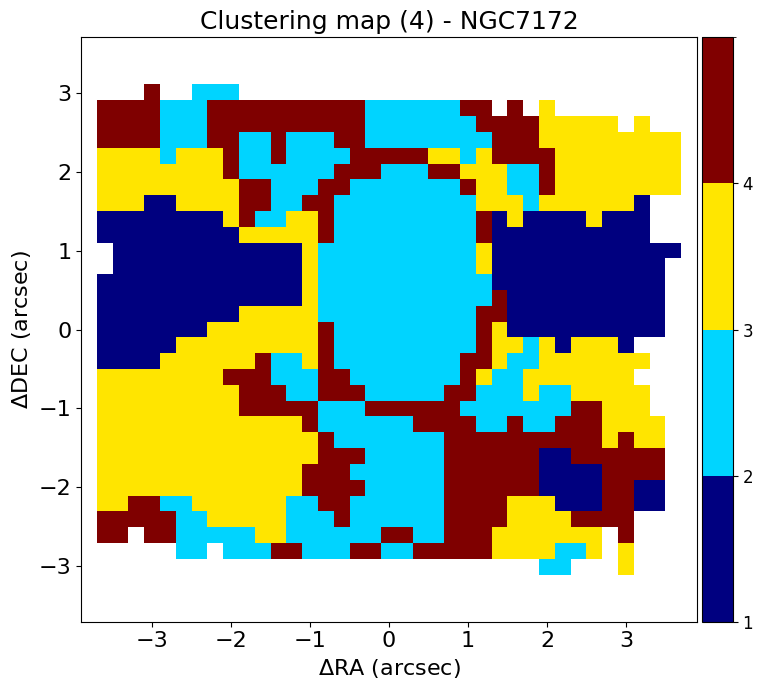

In [20]:
# === Plot cluster map ===
# Plot the clusters as a 2D map

################
# Do you want to save the figure?
save_fig = False
################

import matplotlib.colors as mcolors
fig, ax = plt.subplots(figsize=(8,7))

# Build a color map with one color per cluster (handle NaNs)
nmax = int(np.nanmax(clusters)) if not np.isnan(np.nanmax(clusters)) else 0
colors = plt.cm.jet(np.linspace(0, 1, nmax+1))
cmap, norm = mcolors.from_levels_and_colors(range(nmax+2), colors)

# Compute extent if available (fall back to image indices)
try:
    import astropy.units as u
    cdelt1 = cb.header['CDELT1']*u.deg.to(u.arcsec)
    cdelt2 = cb.header['CDELT2']*u.deg.to(u.arcsec)
    extent = [-cdelt1*cb.header['NAXIS1']/2, cdelt1*(cb.header['NAXIS1']/2), -cdelt2*(cb.header['NAXIS2']/2), cdelt2*(cb.header['NAXIS2']/2)]
except Exception:
    extent = None

im = ax.imshow(clusters, cmap=cmap, norm=norm, origin='lower', interpolation='none', extent=extent)
ax.set_title(f'Clustering map ({n_clusters}) - {gal}', fontsize=18)
ax.set_xlabel('$\Delta$RA (arcsec)' if extent is not None else 'X (pix)', fontsize=16)
ax.set_ylabel('$\Delta$DEC (arcsec)' if extent is not None else 'Y (pix)', fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=16)
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.05)
cbar = plt.colorbar(im, cax=cax)
cbar.set_ticks([i for i in range(nmax+1)])
cbar.set_ticklabels([str(i+1) for i in range(nmax+1)])
cbar.ax.tick_params(labelsize=12)
plt.tight_layout()
plt.show()

# Save figure. 
if save_fig:
    fig.savefig(os.path.join(SavePath, f'clusters_map_{n_clusters}_{date}.png'), dpi=150, bbox_inches='tight')
    print('[INFO]: Saved cluster map to', SavePath)


### Plot the median spectra per cluster

[INFO]: Obtaining median spectra per cluster...


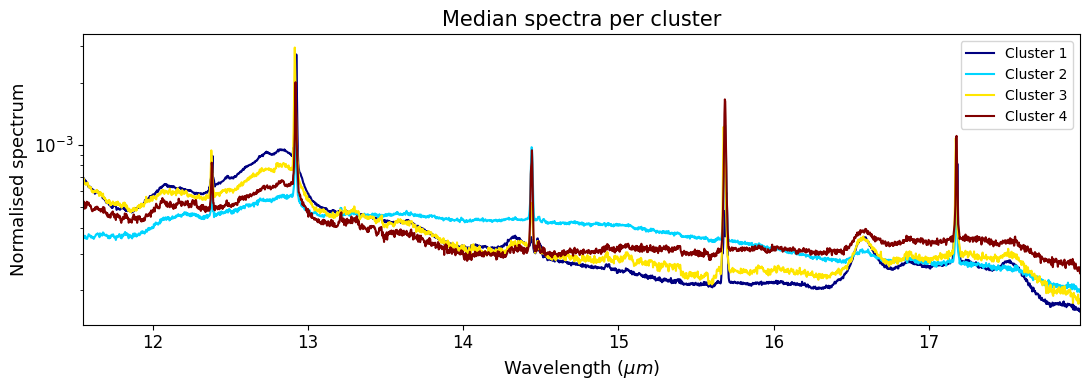

In [24]:
# === Plot median spectrum per cluster (matplotlib) ===

# This step plots the median spectrum for each cluster.
# Obtain the median spectra from the created class, and plot them individually.

# IMPORTANT NOTE:
# Some times, depending on the number of clusters, there can be issues obtaining
# the median spectra. Hence, a try-except block is used here.
# Change the number in the if condition if needed to plot the number of clusters you have.

try:
    print('[INFO]: Obtaining median spectra per cluster...')
    if hcl.n <= 5:
        median_spectra = [hcl.get_cluster_median(i) for i in range(0, hcl.n)]
    else:
        median_spectra = [hcl.get_cluster_median(i) for i in range(0, hcl.n+1)]
except Exception as e:
    print('Error obtaining median spectra:', e)
    median_spectra = []

if len(median_spectra) > 0:
    plt.figure(figsize=(11,4))
    colors = plt.cm.jet(np.linspace(0,1,len(median_spectra)))
    # cb.lambdas is expected to be the wavelength array in your cube class
    lam = getattr(cb, 'lambdas', None)
    if lam is None:
        # fallback to indices
        lam = np.arange(median_spectra[0].size)
    for i, m in enumerate(median_spectra):
        plt.plot(lam, m, label=f'Cluster {i+1}', color=colors[i])
    plt.xlim(lam[0], lam[-1])
    plt.tick_params(axis='both', which='major', labelsize=12)
    plt.yscale('log')
    plt.xlabel('Wavelength ($\mu m$)', fontsize=13)
    plt.ylabel('Normalised spectrum', fontsize=13)
    plt.title('Median spectra per cluster', fontsize=15)
    plt.legend(fontsize=10)
    plt.tight_layout()
    # Save figure.
    if save_fig:
        plt.savefig(os.path.join(SavePath, f'median_spectra_{n_clusters}_{date}.png'), dpi=150, bbox_inches='tight')
        print('[INFO]: Saved median spectra plot to', SavePath)
    plt.show()
else:
    print('[INFO]: No median spectra available to plot.')


### Plot the mean, median, and std of the spectra in a given cluster

This is an optional plot, that takes into account all the spaxels used for creating a given cluster, to estimate the basic properties.

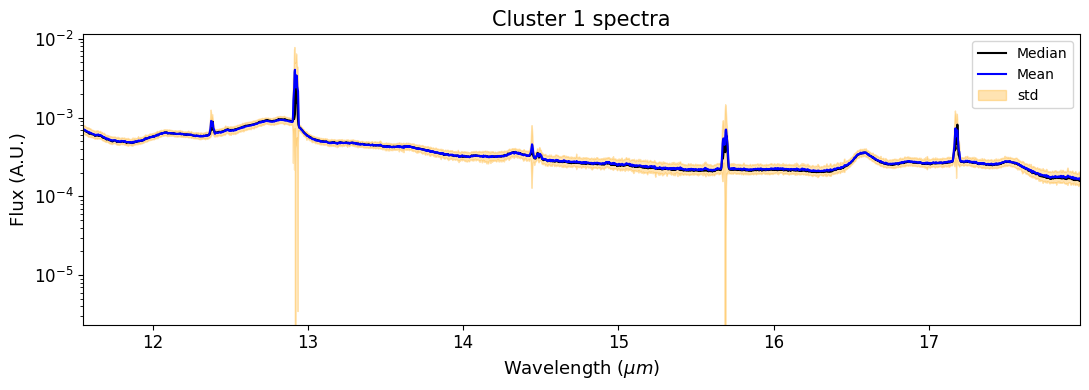

In [29]:
# === Quick plotting helper: show integrated spectrum of a single cluster ===

# This function plots the mean, median and std of the spectra in a given cluster.
# It takes into account all spectra assigned to that cluster.

def plot_cluster_spectra(cluster_id):
    mean_spectrum, median_spectrum, std = hcl.get_metrics_in_cluster(cluster_id)
    lam = getattr(cb, 'lambdas', np.arange(median_spectrum.size))
    plt.figure(figsize=(11,4))
    plt.plot(lam, median_spectrum, color='black', label='Median')
    plt.plot(lam, mean_spectrum, color='blue', label='Mean')
    plt.fill_between(lam, mean_spectrum-std, mean_spectrum+std, color='orange', alpha=0.3, label='std')
    plt.xlim(lam[0], lam[-1])
    plt.tick_params(axis='both', which='major', labelsize=12)
    plt.yscale('log')
    plt.xlabel('Wavelength ($\mu m$)', fontsize=13)
    plt.ylabel('Flux (A.U.)', fontsize=13)
    plt.title(f'Cluster {cluster_id+1} spectra', fontsize=15)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Example: plot cluster 0 (change index as needed)
plot_cluster_spectra(0)
